In [4]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ======================================================
# Directories
# ======================================================

DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ======================================================
# Columns & targets
# ======================================================

EXCLUDE_COLS = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss"
}


# ======================================================
# Helper Functions
# ======================================================

def load_split_data():
    """Loads train/valid/test CSVs."""
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    """Auto-detect numeric features and extract target columns."""
    df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns], errors="ignore")
    df_num = df.select_dtypes(include=[np.number])

    feature_cols = [c for c in df_num.columns if c not in TARGETS.values()]
    X = df_num[feature_cols].fillna(0)
    y = {name: df_num[col].fillna(0) for name, col in TARGETS.items()}

    return X, y, feature_cols


# ======================================================
# XGBoost Training for a Single Target
# ======================================================
def train_xgb_single(X_train, X_valid, X_test, y_train, y_valid, y_test, model_name):
    """
    XGBoost training compatible with OLD XGBoost versions.
    """

    print(f"\n==================== XGBOOST MODEL: {model_name} ====================")

    # XGBoost Regressor (old-version safe)
    model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="auto",     # 'hist' may not exist in old versions
        random_state=42,
        n_jobs=-1
    )

    # ==== TRAIN (NO early stopping, NO eval metric) ====
    model.fit(X_train, y_train)

    # Save model
    model_path = os.path.join(MODEL_DIR, f"xgb_model_{model_name.lower()}.json")
    model.save_model(model_path)
    print(f"Saved XGB model → {model_path}")

    # Predictions
    y_valid_pred = model.predict(X_valid)
    y_test_pred  = model.predict(X_test)

    # Evaluation
    val_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    val_mae  = mean_absolute_error(y_valid, y_valid_pred)
    val_r2   = r2_score(y_valid, y_valid_pred)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_r2   = r2_score(y_test, y_test_pred)

    print("Validation:")
    print(f"  RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")
    print("Test:")
    print(f"  RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

    # Save predictions
    valid_path = os.path.join(PRED_DIR, f"xgb_{model_name}_valid_predictions.csv")
    test_path  = os.path.join(PRED_DIR, f"xgb_{model_name}_test_predictions.csv")

    pd.DataFrame({"y_true": y_valid, "y_pred": y_valid_pred}).to_csv(valid_path, index=False)
    pd.DataFrame({"y_true": y_test,  "y_pred": y_test_pred}).to_csv(test_path, index=False)

    print(f"Validation predictions saved → {valid_path}")
    print(f"Test predictions saved → {test_path}")

    return {
        "Model": model_name,
        "Val_RMSE": val_rmse,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    }



# ======================================================
# Full XGBoost Pipeline
# ======================================================

def train_xgb_pipeline():
    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _ = extract_xy(df_valid)
    X_test,  y_test_dict, _  = extract_xy(df_test)

    results = []

    for model_name in TARGETS.keys():
        res = train_xgb_single(
            X_train, X_valid, X_test,
            y_train_dict[model_name],
            y_valid_dict[model_name],
            y_test_dict[model_name],
            model_name,
        )
        results.append(res)

    print("\n==================== XGBOOST FINAL SUMMARY ====================")
    for r in results:
        print(r)

    return results


# ======================================================
# Run Script
# ======================================================

if __name__ == "__main__":
    train_xgb_pipeline()



==================== XGBOOST MODEL: Throughput ====================
Saved XGB model → ../outputs/models/xgb_model_throughput.json
Validation:
  RMSE: 0.0535, MAE: 0.0535, R²: 0.0000
Test:
  RMSE: 0.0024, MAE: 0.0024, R²: 0.0000
Validation predictions saved → ../outputs/models/predictions/xgb_Throughput_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/xgb_Throughput_test_predictions.csv

==================== XGBOOST MODEL: Latency ====================
Saved XGB model → ../outputs/models/xgb_model_latency.json
Validation:
  RMSE: 13.2480, MAE: 13.2480, R²: 0.0000
Test:
  RMSE: 7.3269, MAE: 7.3269, R²: -4253194060007036176990382063616.0000
Validation predictions saved → ../outputs/models/predictions/xgb_Latency_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/xgb_Latency_test_predictions.csv

==================== XGBOOST MODEL: Loss ====================
Saved XGB model → ../outputs/models/xgb_model_loss.json
Validation:
  RMSE: 0.82

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"

os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = ["Throughput", "Latency", "Loss"]

plt.style.use("seaborn-v0_8-whitegrid")


# ============================================================
# 1. Load XGB Predictions
# ============================================================

def load_xgb_predictions(model_name, split):
    """
    split ∈ {'valid', 'test'}
    Loads: xgb_{model_name}_{split}_predictions.csv
    """
    path = os.path.join(PRED_DIR, f"xgb_{model_name}_{split}_predictions.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing XGB prediction file → {path}")

    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


# ============================================================
# 2. Scatter Plot: Predicted vs Actual
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(7, 6))

    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor=None)

    # Identity line
    lo = min(min(y_true), min(y_pred))
    hi = max(max(y_true), max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'r--', label="Ideal")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# 3. Time-Series Plot
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(10, 5))

    plt.plot(y_true.values, label="Actual", color="blue", linewidth=2)
    plt.plot(y_pred, label="Predicted", color="orange", linestyle="--", linewidth=2)

    plt.xlabel("Sample Index (Interval Order)")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# 4. Generate All XGB Plots
# ============================================================

def generate_xgb_plots(showImage=False):

    for model_name in MODELS:
        print(f"\n=== XGB Plots for {model_name} ===")

        # ------------------------------------------
        # Validation Plots
        # ------------------------------------------
        yv, yv_pred = load_xgb_predictions(model_name, "valid")

        # Scatter
        valid_scatter_path = os.path.join(
            PLOT_DIR, f"xgb_{model_name}_pred_vs_actual_valid.png"
        )
        plot_pred_vs_actual(
            yv, yv_pred,
            title=f"XGB {model_name} – Predicted vs Actual (Validation)",
            outfile=valid_scatter_path,
            showImage=showImage
        )

        # Time-series
        valid_ts_path = os.path.join(
            PLOT_DIR, f"xgb_{model_name}_timeseries_valid.png"
        )
        plot_time_series(
            yv, yv_pred,
            title=f"XGB {model_name} – Time-Series (Validation)",
            outfile=valid_ts_path,
            showImage=showImage
        )

        # ------------------------------------------
        # Test Plots
        # ------------------------------------------
        yt, yt_pred = load_xgb_predictions(model_name, "test")

        # Scatter
        test_scatter_path = os.path.join(
            PLOT_DIR, f"xgb_{model_name}_pred_vs_actual_test.png"
        )
        plot_pred_vs_actual(
            yt, yt_pred,
            title=f"XGB {model_name} – Predicted vs Actual (Test)",
            outfile=test_scatter_path,
            showImage=showImage
        )

        # Time-series
        test_ts_path = os.path.join(
            PLOT_DIR, f"xgb_{model_name}_timeseries_test.png"
        )
        plot_time_series(
            yt, yt_pred,
            title=f"XGB {model_name} – Time-Series (Test)",
            outfile=test_ts_path,
            showImage=showImage
        )

    print("\nAll XGB plots generated successfully!")



=== XGB Plots for Throughput ===


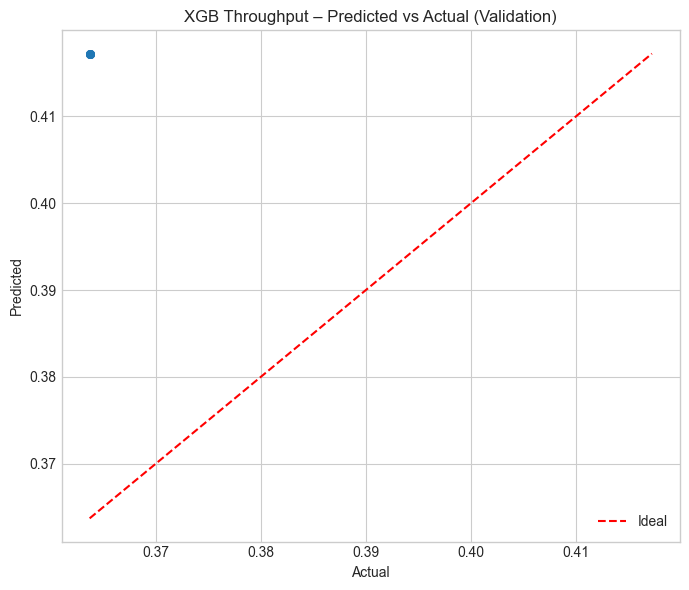

Saved → ../outputs/models/plots/xgb_Throughput_pred_vs_actual_valid.png


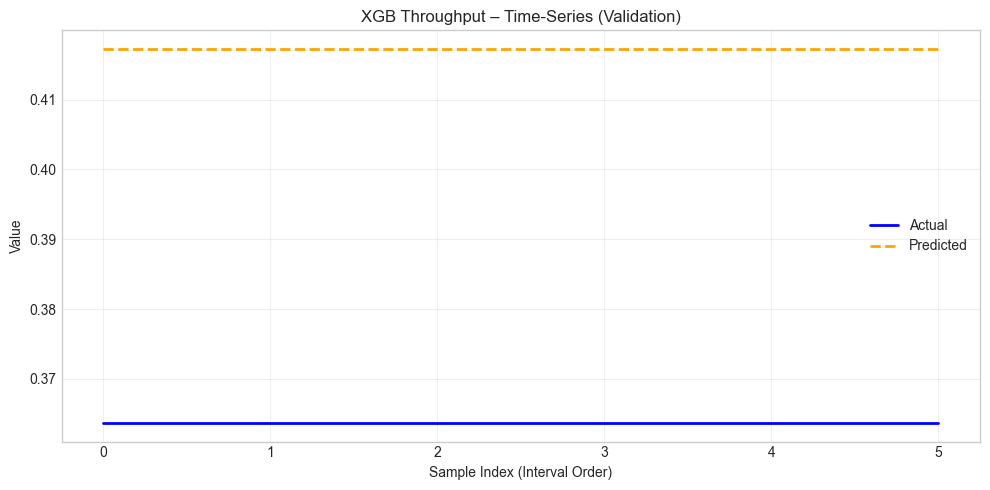

Saved → ../outputs/models/plots/xgb_Throughput_timeseries_valid.png


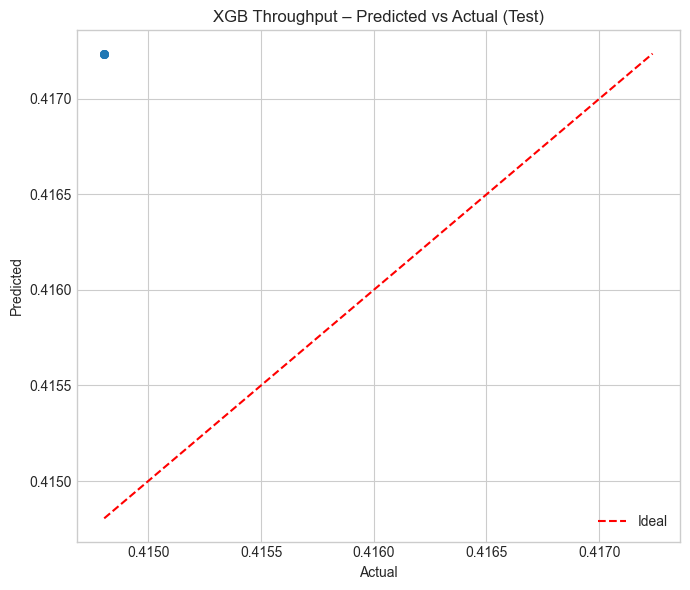

Saved → ../outputs/models/plots/xgb_Throughput_pred_vs_actual_test.png


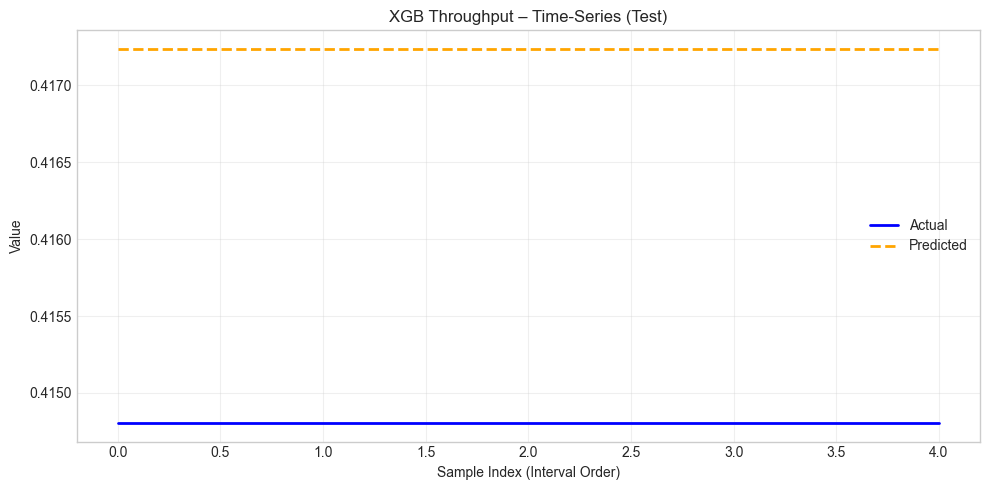

Saved → ../outputs/models/plots/xgb_Throughput_timeseries_test.png

=== XGB Plots for Latency ===


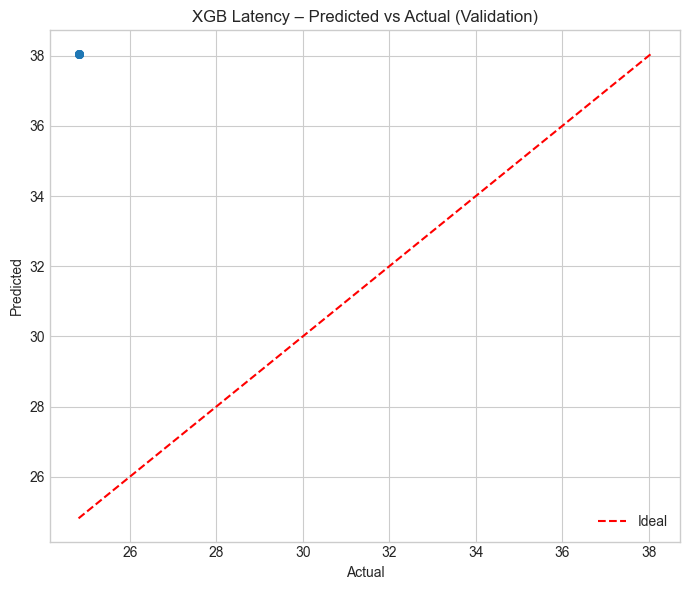

Saved → ../outputs/models/plots/xgb_Latency_pred_vs_actual_valid.png


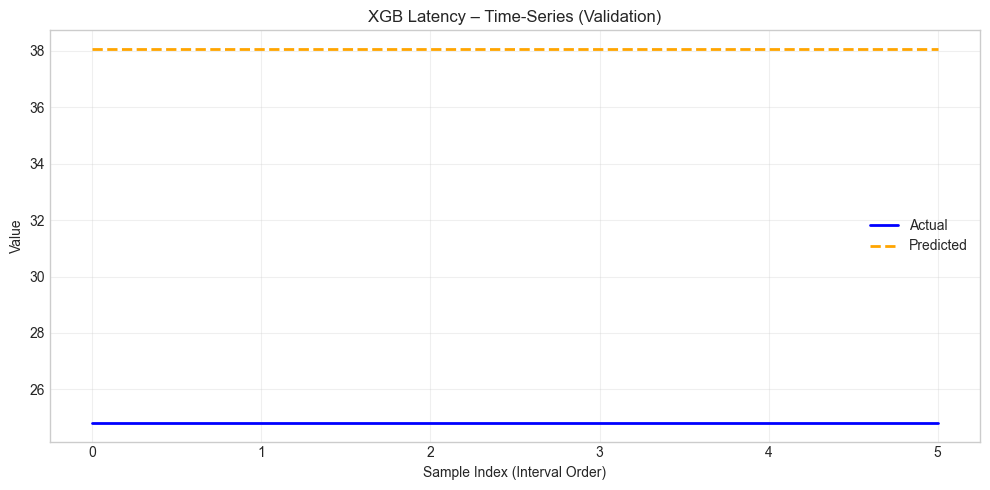

Saved → ../outputs/models/plots/xgb_Latency_timeseries_valid.png


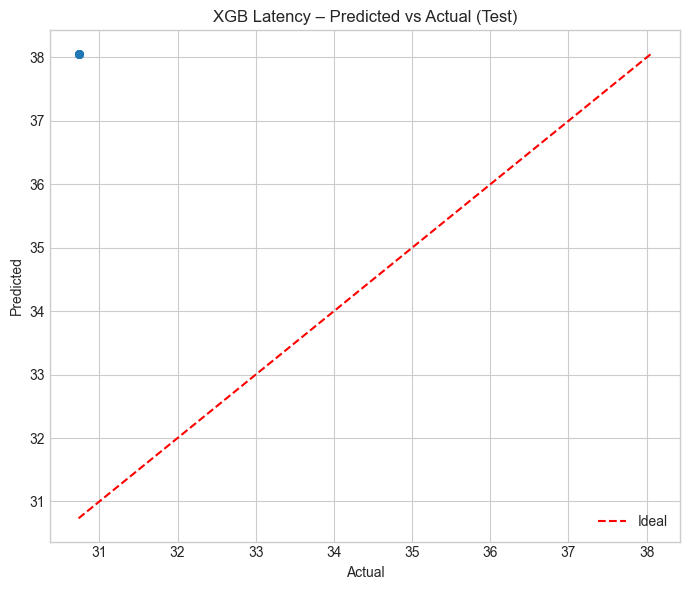

Saved → ../outputs/models/plots/xgb_Latency_pred_vs_actual_test.png


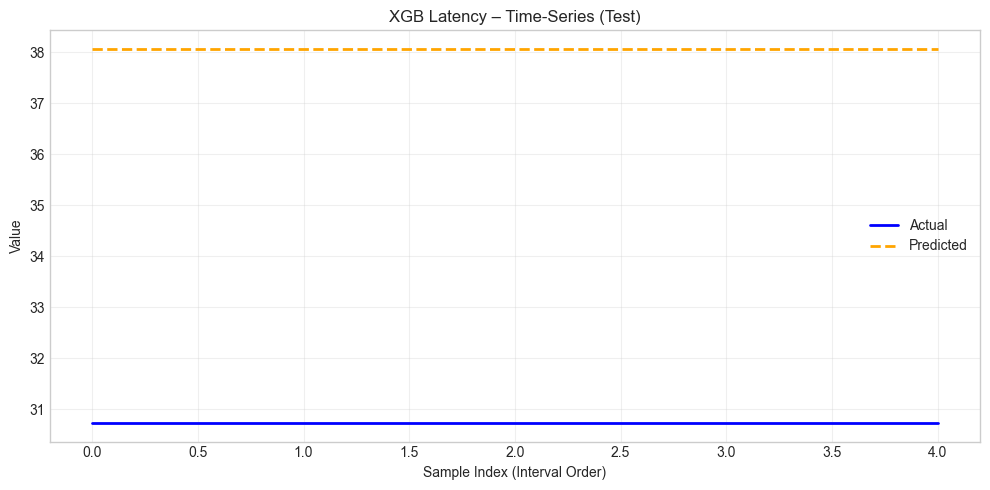

Saved → ../outputs/models/plots/xgb_Latency_timeseries_test.png

=== XGB Plots for Loss ===


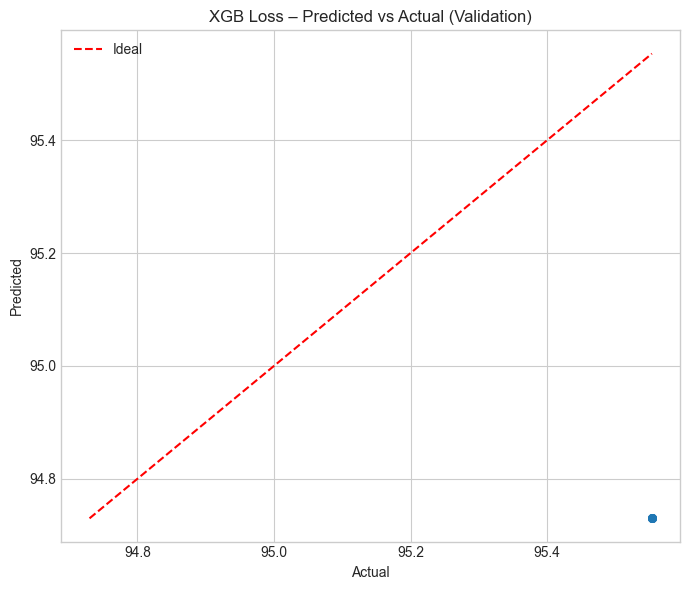

Saved → ../outputs/models/plots/xgb_Loss_pred_vs_actual_valid.png


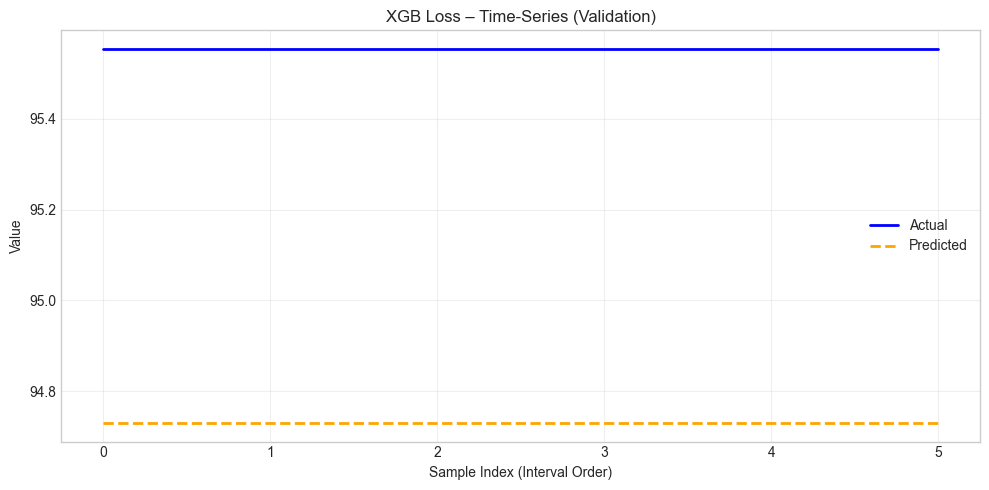

Saved → ../outputs/models/plots/xgb_Loss_timeseries_valid.png


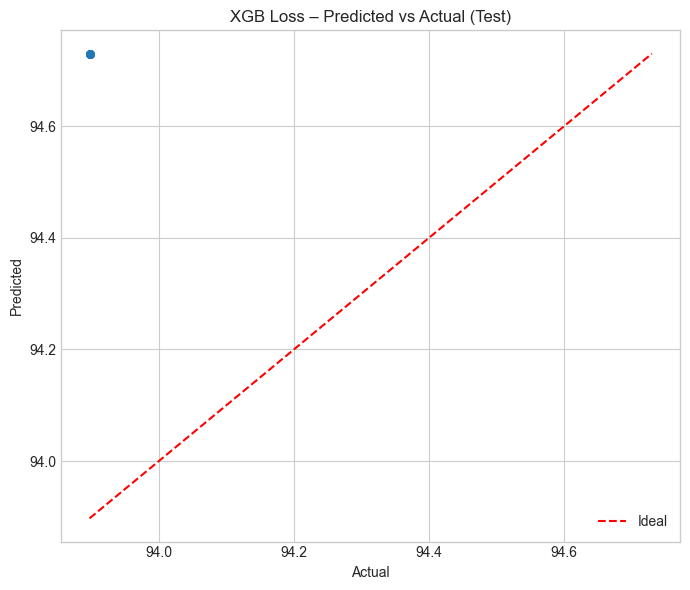

Saved → ../outputs/models/plots/xgb_Loss_pred_vs_actual_test.png


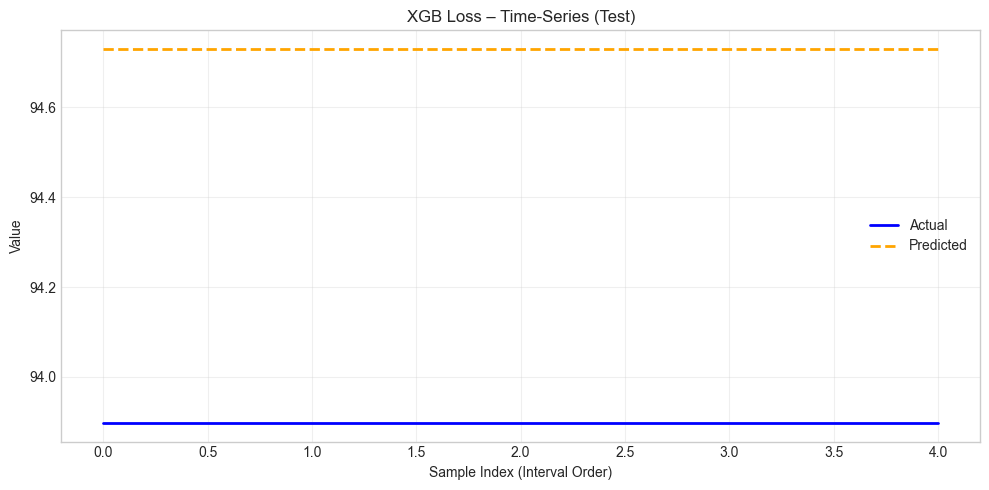

Saved → ../outputs/models/plots/xgb_Loss_timeseries_test.png

All XGB plots generated successfully!


In [7]:
# from xgb_plots import generate_xgb_plots
generate_xgb_plots(showImage=True)


In [13]:
import os
import time
import numpy as np
import xgboost as xgb


# =====================================================================
# 1. Load XGBoost Model from File
# =====================================================================

def load_xgb_model(model_path):
    """
    Loads an XGBoost model (old or new versions).
    """
    bst = xgb.Booster()
    bst.load_model(model_path)
    return bst


# =====================================================================
# 2. Extract Tree Structure Stats (depth, nodes, #trees)
# =====================================================================

def xgb_structure_stats(bst):
    """
    Extract tree complexity:
    - number of trees
    - total nodes
    - average nodes per tree
    - average tree depth
    - max tree depth
    """
    dump = bst.get_dump(with_stats=True)

    n_trees = len(dump)
    total_nodes = 0
    depths = []

    for tree_text in dump:
        lines = tree_text.strip().split("\n")

        node_count = len(lines)
        total_nodes += node_count

        # Estimate depth by counting indentation or node ids
        depth = max(line.count('\t') for line in lines)
        depths.append(depth)

    avg_depth = float(np.mean(depths))
    max_depth = max(depths)
    avg_nodes = total_nodes / n_trees

    return {
        "n_trees": n_trees,
        "total_nodes": total_nodes,
        "avg_nodes_per_tree": avg_nodes,
        "avg_tree_depth": avg_depth,
        "max_tree_depth": max_depth
    }


# =====================================================================
# 3. Model Size (bytes & MB)
# =====================================================================

def xgb_model_size(model_path):
    size = os.path.getsize(model_path)
    return size, size / (1024 * 1024)  # bytes, MB


# =====================================================================
# 4. Inference Latency (Measured)
# =====================================================================

def measure_xgb_latency(bst, X_sample, runs=200, warmup=20):
    """
    X_sample must be numpy array (1, n_features)
    """

    dtest = xgb.DMatrix(X_sample)

    # Warmup
    for _ in range(warmup):
        _ = bst.predict(dtest)

    # Measured runs
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = bst.predict(dtest)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


# =====================================================================
# 5. Estimated Energy
# =====================================================================

def estimate_energy(latency, power_W=2.0):
    """
    E = P × t
    """
    return latency * power_W


# =====================================================================
# 6. Main Edge Evaluation Function
# =====================================================================

def evaluate_xgb_edge(model_path, X_sample, assumed_power_W=2.0):
    bst = load_xgb_model(model_path)

    # Structure metrics
    struct = xgb_structure_stats(bst)

    # Model size
    size_bytes, size_mb = xgb_model_size(model_path)

    # Latency
    latency = measure_xgb_latency(bst, X_sample)

    # Energy
    energy = estimate_energy(latency, assumed_power_W)

    # Peak activation memory
    peak_activation_bytes = X_sample.to_numpy().nbytes

    return {
        "Model Path": model_path,
        "Trees": struct["n_trees"],
        "Total Nodes": struct["total_nodes"],
        "Average Nodes per Tree": struct["avg_nodes_per_tree"],
        "Average Tree Depth": struct["avg_tree_depth"],
        "Max Tree Depth": struct["max_tree_depth"],
        "Model Size (Bytes)": size_bytes,
        "Model Size (MB)": size_mb,
        "Latency (s)": latency,
        "Latency (ms)": latency * 1000,
        "Energy Estimated (J)": energy,
        "Peak Activation Memory (Bytes)": peak_activation_bytes
    }



In [14]:
import pandas as pd
import numpy as np
# from xgb_edge_evaluation import evaluate_xgb_edge

# Load feature names from train.csv (must match XGB training)
df_train = pd.read_csv("../outputs/datasets/train.csv")
feature_cols = [c for c in df_train.columns 
                if c not in ["Perf_Avg_Throughput", "Perf_Avg_Latency", "Perf_Avg_Loss",
                             "StartDateTime", "EndDateTime", "Perf_Filename", 
                             "ND_Filename", "RunDateTime"]]

# Create sample with correct feature names
X_sample = pd.DataFrame([np.random.randn(len(feature_cols))], columns=feature_cols)

model_path = "../outputs/models/xgb_model_throughput.json"

metrics = evaluate_xgb_edge(model_path, X_sample)
print(metrics)


{'Model Path': '../outputs/models/xgb_model_throughput.json', 'Trees': 400, 'Total Nodes': 400, 'Average Nodes per Tree': 1.0, 'Average Tree Depth': 0.0, 'Max Tree Depth': 0, 'Model Size (Bytes)': 164547, 'Model Size (MB)': 0.15692424774169922, 'Latency (s)': 0.0006393994996324181, 'Latency (ms)': 0.6393994996324182, 'Energy Estimated (J)': 0.0012787989992648363, 'Peak Activation Memory (Bytes)': 824}
